<a href="https://colab.research.google.com/github/mszhdgr/Machine_learning/blob/Main/Time%20Series/arima_timeseries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gvyshnya/gold-future-prices")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'gold-future-prices' dataset.
Path to dataset files: /kaggle/input/gold-future-prices


In [3]:
import pandas as pd

df = pd.read_csv("/kaggle/input/gold-future-prices/future-gc00-daily-prices.csv")
df.head()

,Date,Open,High,Low,Close
0,01/02/2013,"1,676.40","1,695.40","1,670.90","1,688.80"
1,01/02/2014,"1,204.50","1,230.80","1,202.50","1,225.20"
2,01/02/2015,"1,184.00","1,194.90","1,167.30","1,186.20"
3,01/02/2018,"1,305.30","1,320.40","1,304.60","1,316.10"
4,01/02/2019,"1,285.00","1,291.00","1,280.60","1,284.10"


In [5]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df = df.set_index('Date')
df.head()

,Open,High,Low,Close
Date,,,,
2009-04-24,905.50,915.40,904.20,914.10
2009-04-27,915.00,919.70,905.80,908.20
2009-04-28,907.20,907.70,884.60,893.60
2009-04-29,894.00,904.00,888.30,900.50
2009-04-30,898.60,900.80,880.10,891.20


In [6]:
ts = df['Close']
ts

,Close
Date,
2009-04-24,914.10
2009-04-27,908.20
2009-04-28,893.60
2009-04-29,900.50
2009-04-30,891.20
...,...
2024-02-02,"2,053.70"
2024-02-05,"2,042.90"
2024-02-06,"2,051.40"


In [6]:
df.isna().sum()

,0
Open,0
High,0
Low,0
Close,0
clean_Close,0


In [16]:
df_filtered = df.loc['2009':'2011']
df_filtered.head()

,Open,High,Low,Close
Date,,,,
2009-04-24,905.50,915.40,904.20,914.10
2009-04-27,915.00,919.70,905.80,908.20
2009-04-28,907.20,907.70,884.60,893.60
2009-04-29,894.00,904.00,888.30,900.50
2009-04-30,898.60,900.80,880.10,891.20


In [17]:
len(df_filtered)

679

In [33]:
df_filtered['Close']

,Close
2009-04-24,904.967142
2009-04-27,903.584499
2009-04-28,910.061384
2009-04-29,925.291682
2009-04-30,922.950149
...,...
2011-11-24,822.073551
2011-11-25,814.295384
2011-11-28,803.189625
2011-11-29,820.712330


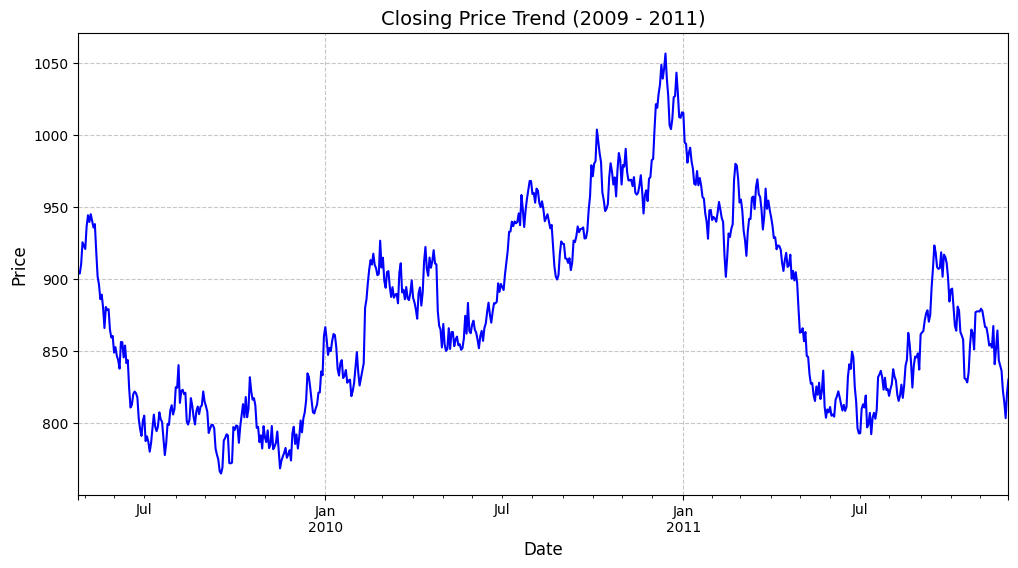

In [34]:
import matplotlib.pyplot as plt

df_filtered['Close'].plot(figsize=(12, 6), color='blue', linewidth=1.5)

plt.title('Closing Price Trend (2009 - 2011)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

In [35]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df_filtered['Close'])

In [36]:
result

(np.float64(-1.9346403282936018),
 np.float64(0.3159447152324373),
 0,
 678,
 {'1%': np.float64(-3.4400317565062455),
  '5%': np.float64(-2.8658123184971576),
  '10%': np.float64(-2.56904513726821)},
 np.float64(4885.844371258794))

In [37]:
result[0]

np.float64(-1.9346403282936018)

In [38]:
result[1]

np.float64(0.3159447152324373)

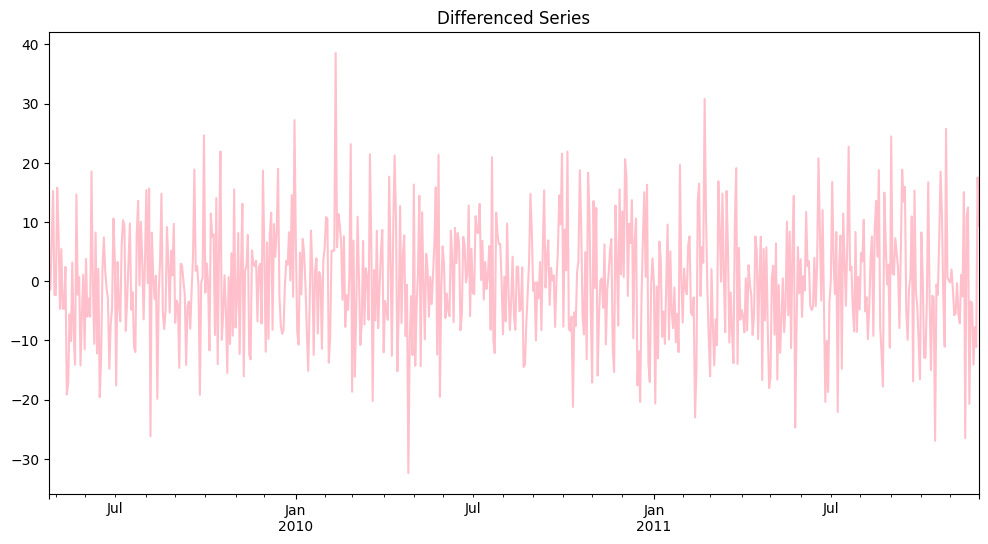

In [44]:
df_filtered['Close_diff'] = df_filtered['Close'].diff()

df_filtered['Close_diff'].plot(figsize=(12,6), color='pink', linewidth=1.5)
plt.title("Differenced Series")
plt.show()

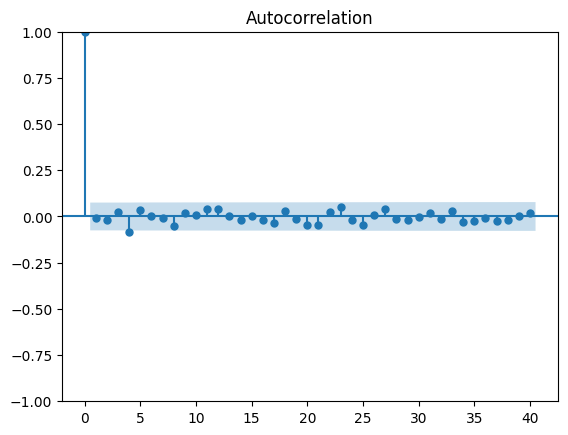

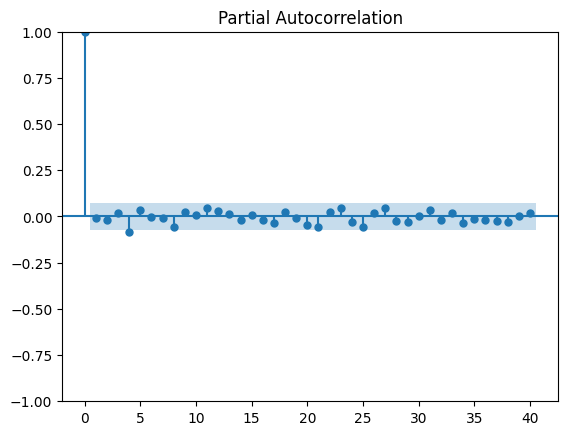

In [47]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df_filtered['Close_diff'].dropna(), lags=40)
plot_pacf(df_filtered['Close_diff'].dropna(), lags=40)
plt.show()


In [48]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df_filtered['Close'], order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  679
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -2515.642
Date:                Sun, 12 Apr 2026   AIC                           5037.284
Time:                        14:52:19   BIC                           5050.841
Sample:                    04-24-2009   HQIC                          5042.532
                         - 11-30-2011                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8733      0.124     -7.032      0.000      -1.117      -0.630
ma.L1          0.9056      0.109      8.307      0.000       0.692       1.119
sigma2        97.7936      5.087     19.223      0.0

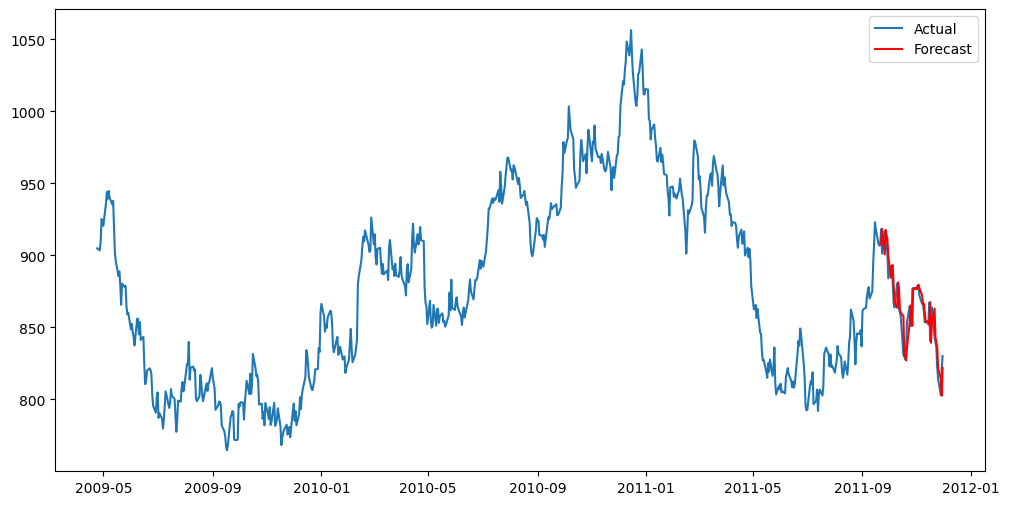

In [49]:
forecast = model_fit.predict(start=len(df_filtered)-50, end=len(df_filtered)-1, typ='levels')

plt.figure(figsize=(12,6))
plt.plot(df_filtered['Close'], label='Actual')
plt.plot(forecast, label='Forecast', color='red')
plt.legend()
plt.show()


In [50]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(df_filtered['Close'][-50:], forecast))
print("RMSE:", rmse)


RMSE: 11.425076572681665
